In [1]:
# Fashion MNIST CNN Classifier
# Import Required Libraries

import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt

In [2]:
# Load Dataset
data = pd.read_csv("fashion-mnist_test.csv")

# Display first 5 rows
print(data.head())

   label  pixel1  pixel2  pixel3  pixel4  pixel5  pixel6  pixel7  pixel8  \
0      0       0       0       0       0       0       0       0       9   
1      1       0       0       0       0       0       0       0       0   
2      2       0       0       0       0       0       0      14      53   
3      2       0       0       0       0       0       0       0       0   
4      3       0       0       0       0       0       0       0       0   

   pixel9  ...  pixel775  pixel776  pixel777  pixel778  pixel779  pixel780  \
0       8  ...       103        87        56         0         0         0   
1       0  ...        34         0         0         0         0         0   
2      99  ...         0         0         0         0        63        53   
3       0  ...       137       126       140         0       133       224   
4       0  ...         0         0         0         0         0         0   

   pixel781  pixel782  pixel783  pixel784  
0         0         0         

In [3]:
# Separate labels and image pixels
y = data['label']
X = data.drop('label', axis=1)


In [4]:
# Normalize pixel values
X = X / 255.0

In [5]:
# Convert into numpy arrays
X = np.array(X)
y = np.array(y)

In [6]:
# Reshape images for CNN
X = X.reshape(-1, 28, 28, 1)

In [7]:
# Class Names
class_names = [
    'T-shirt',
    'Trouser',
    'Pullover',
    'Dress',
    'Coat',
    'Sandal',
    'Shirt',
    'Sneaker',
    'Bag',
    'Ankle Boot'
]

In [8]:
# Build CNN Model
model = keras.Sequential([
    # Input Layer
    keras.Input(shape=(28, 28, 1)),
    # First Convolution Layer
    layers.Conv2D(32, (3,3), activation='relu'),
    # First Pooling Layer
    layers.MaxPooling2D((2,2)),
    # Second Convolution Layer
    layers.Conv2D(64, (3,3), activation='relu'),
    # Second Pooling Layer
    layers.MaxPooling2D((2,2)),
    # Flatten Layer
    layers.Flatten(),
    # Dense Layer
    layers.Dense(128, activation='relu'),
    # Output Layer
    layers.Dense(10, activation='softmax')
])


In [9]:
# Compile Model
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])


In [10]:
# Train Model
model.fit(X, y, epochs=5)

Epoch 1/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 20ms/step - accuracy: 0.7454 - loss: 0.7025
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 10s 19ms/step - accuracy: 0.8410 - loss: 0.4392
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 9s 16ms/step - accuracy: 0.8637 - loss: 0.3758
Epoch 4/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 20ms/step - accuracy: 0.8771 - loss: 0.3332
Epoch 5/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.8924 - loss: 0.2908


In [11]:
# Evaluate Model
loss, accuracy = model.evaluate(X, y)

# Print Accuracy
print("\nAccuracy:", accuracy)

# Predict Images
prediction = model.predict(X)

# Get First Image Prediction
predicted_class = class_names[np.argmax(prediction[0])]

print("\nPredicted Class:", predicted_class)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8912 - loss: 0.2935

Accuracy: 0.8912000060081482
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step

Predicted Class: T-shirt


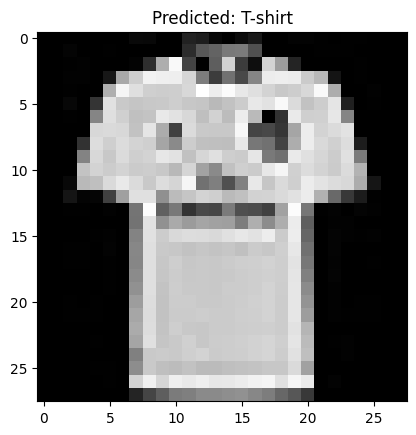

In [12]:
# Display First Image
plt.imshow(X[0].reshape(28,28), cmap='gray')

plt.title("Predicted: " + predicted_class)

plt.show()